## K-means Sampling N Cluster

Email Phishing Dataset Clustering with PhishingBERT
Configuration:
- Number of clusters: 5
- Samples per cluster: 100
- Balanced sampling: True
- Data path: ../raw/email_phishing_CEAS-08_train.csv.gz
- Output directory: ../raw/CEAS-08_train_cluster/

1. LOADING AND EXPLORING DATA
✓ Dataset loaded successfully
Dataset shape: (2000, 4)
Columns: ['subject', 'body', 'label', 'source']

Label distribution:
label
1    1000
0    1000
Name: count, dtype: int64

Source distribution:
source
CEAS-08    2000
Name: count, dtype: int64

Missing values: 1
Text length statistics:
- Mean length: 1645.2
- Max length: 55578
- Min length: 36

2. PHISHINGBERT VECTORIZATION
Loading model: martin-ha/toxic-comment-model
Using device: cpu
Generating embeddings for 2000 texts...


Generating embeddings: 100%|██████████| 125/125 [04:25<00:00,  2.12s/it]


✓ Embeddings generated: (2000, 768)

3. CLUSTERING ANALYSIS


Finding optimal clusters: 100%|██████████| 14/14 [00:11<00:00,  1.18it/s]


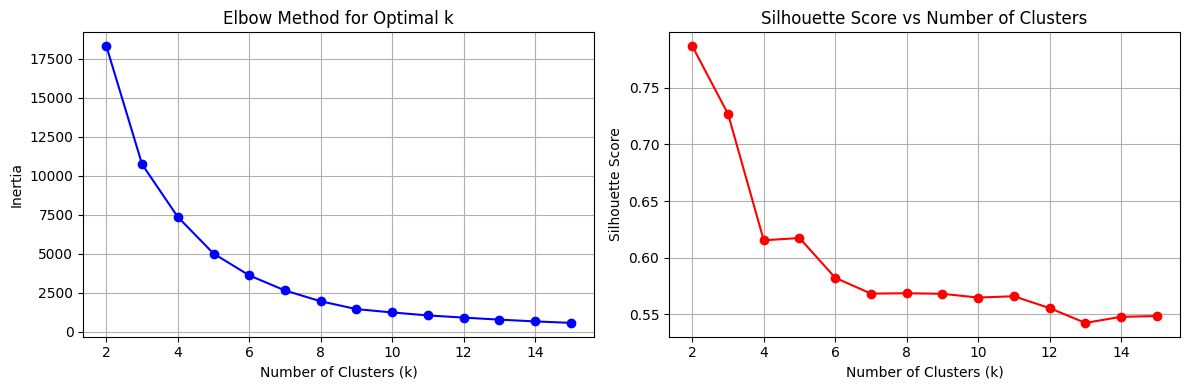

✓ Clustering metrics plot saved

Performing K-means clustering with 5 clusters...
✓ Clustering completed
Silhouette score: 0.6174

Cluster distribution:
  Cluster 0: 471 samples
  Cluster 1: 1303 samples
  Cluster 2: 165 samples
  Cluster 3: 56 samples
  Cluster 4: 5 samples

4. VISUALIZATION
Performing PCA...
PCA explained variance: 0.9543
Performing t-SNE...


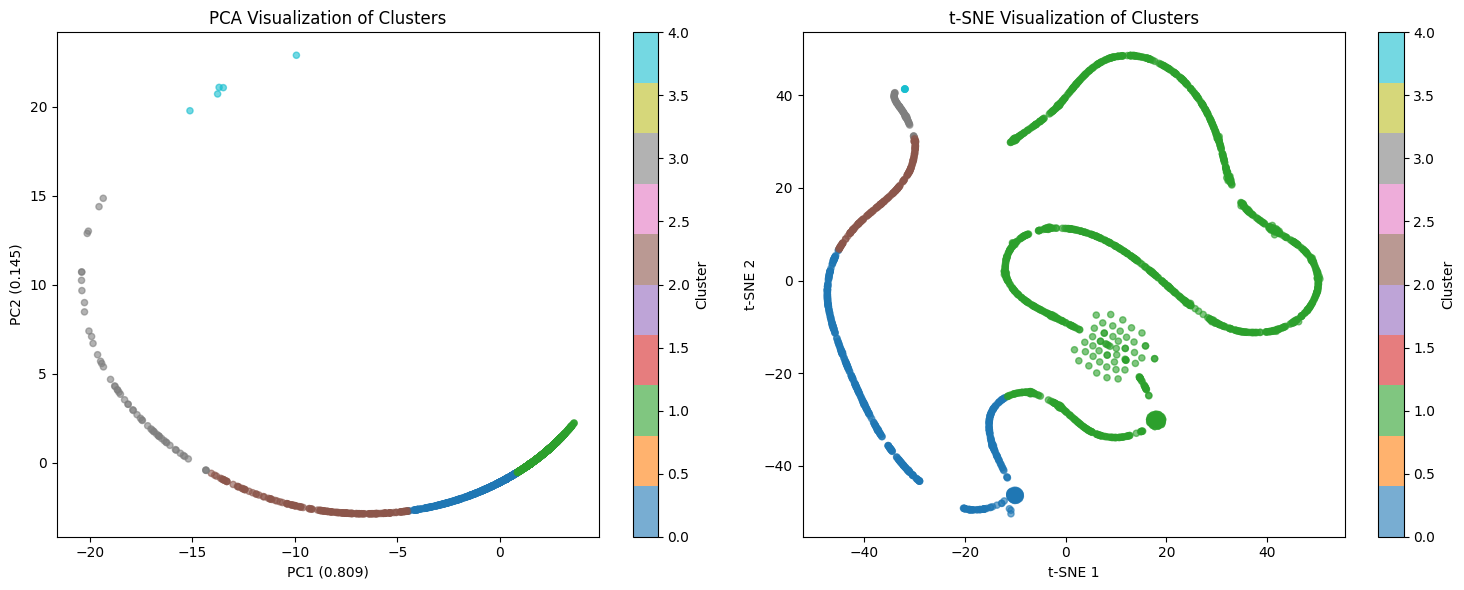

✓ Visualization saved

5. CLUSTER ANALYSIS

--- CLUSTER 0 ---
Size: 471 samples
Label distribution:
  1: 382 (81.1%)
  0: 89 (18.9%)
Sample subjects:
  1. World's finest luxury wrist watches available here...
  2. Who says that wishes cant come true?...
  3. Boost your acting in bed....

--- CLUSTER 1 ---
Size: 1303 samples
Label distribution:
  0: 858 (65.8%)
  1: 445 (34.2%)
Sample subjects:
  1. CNN.com Daily Top 10...
  2. [Fwd: Smoke [5.10.0] 32274 FAIL(M) OSF1 V5.1 (EV6/4 cpu)]...
  3. For you  color="#006646"...

--- CLUSTER 2 ---
Size: 165 samples
Label distribution:
  1: 129 (78.2%)
  0: 36 (21.8%)
Sample subjects:
  1. marsh marsh clarity gaul pica...
  2. Upgrade it to a huge volume...
  3. For men with erectile dysfunction...

--- CLUSTER 3 ---
Size: 56 samples
Label distribution:
  1: 40 (71.4%)
  0: 16 (28.6%)
Sample subjects:
  1. How To Enlarge Penis Size...
  2. Breaking News: N.Y. Jets acquire Brett Favre...
  3. Compare Top 5 Penis Enlargers...

--- CLUSTER 4 ---
Siz

In [1]:
#!/usr/bin/env python3
"""
Email Phishing Dataset Clustering with PhishingBERT
Standalone Python script version
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# For BERT embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import os
import sys

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def main():
    # Configuration
    N_CLUSTER = 5  # Number of clusters to create
    N_SAMPLES_PER_CLUSTER = 100  # Number of samples per cluster
    BALANCED_SAMPLING = True  # Whether to maintain label balance when sampling
    DATA_PATH = "../raw/email_phishing_CEAS-08_train.csv.gz"
    OUTPUT_DIR = "../raw/CEAS-08_train_cluster/"

    # Create output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("Email Phishing Dataset Clustering with PhishingBERT")
    print("=" * 60)
    print("Configuration:")
    print(f"- Number of clusters: {N_CLUSTER}")
    print(f"- Samples per cluster: {N_SAMPLES_PER_CLUSTER}")
    print(f"- Balanced sampling: {BALANCED_SAMPLING}")
    print(f"- Data path: {DATA_PATH}")
    print(f"- Output directory: {OUTPUT_DIR}")

    # 1. Data Loading and Exploration
    print("\n" + "="*50)
    print("1. LOADING AND EXPLORING DATA")
    print("="*50)

    try:
        df = pd.read_csv(DATA_PATH, compression='gzip')
        print(f"✓ Dataset loaded successfully")
    except FileNotFoundError:
        print(f"✗ Error: Could not find file {DATA_PATH}")
        print("Please check the file path and try again.")
        return
    except Exception as e:
        print(f"✗ Error loading dataset: {e}")
        return

    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Check required columns
    required_cols = ['subject', 'body', 'label', 'source']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"✗ Error: Missing required columns: {missing_cols}")
        return

    print("\nLabel distribution:")
    print(df['label'].value_counts())

    print("\nSource distribution:")
    print(df['source'].value_counts())

    # Handle missing values
    print(f"\nMissing values: {df.isnull().sum().sum()}")
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')

    # Create combined text
    df['combined_text'] = df['subject'] + ' ' + df['body']
    df['combined_length'] = df['combined_text'].str.len()

    print(f"Text length statistics:")
    print(f"- Mean length: {df['combined_length'].mean():.1f}")
    print(f"- Max length: {df['combined_length'].max()}")
    print(f"- Min length: {df['combined_length'].min()}")

    # 2. PhishingBERT Model Setup and Vectorization
    print("\n" + "="*50)
    print("2. PHISHINGBERT VECTORIZATION")
    print("="*50)

    # Initialize model
    try:
        model_name = "martin-ha/toxic-comment-model"  # Security-focused model
        print(f"Loading model: {model_name}")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
    except:
        try:
            model_name = "bert-base-uncased"
            print(f"Loading fallback model: {model_name}")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
        except Exception as e:
            print(f"✗ Error loading model: {e}")
            print("Please ensure transformers and torch are installed:")
            print("pip install transformers torch")
            return

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    print(f"Using device: {device}")

    def get_bert_embeddings(texts, batch_size=32, max_length=512):
        """Get BERT embeddings for a list of texts"""
        embeddings = []
        
        for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            
            # Move to device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Get embeddings
            with torch.no_grad():
                outputs = model(**inputs)
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.extend(batch_embeddings)
        
        return np.array(embeddings)

    # Generate embeddings
    texts = df['combined_text'].tolist()
    print(f"Generating embeddings for {len(texts)} texts...")
    
    try:
        embeddings = get_bert_embeddings(texts, batch_size=16)
        print(f"✓ Embeddings generated: {embeddings.shape}")
    except Exception as e:
        print(f"✗ Error generating embeddings: {e}")
        return

    # 3. Clustering Analysis
    print("\n" + "="*50)
    print("3. CLUSTERING ANALYSIS")
    print("="*50)

    def find_optimal_clusters(embeddings, max_k=10):
        """Find optimal number of clusters using elbow method and silhouette score"""
        inertias = []
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(embeddings)//10))
        
        for k in tqdm(k_range, desc="Finding optimal clusters"):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(embeddings)
            inertias.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))
        
        return k_range, inertias, silhouette_scores

    # Find optimal clusters
    try:
        k_range, inertias, silhouette_scores = find_optimal_clusters(embeddings, max_k=15)
        
        # Plot elbow curve
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(k_range, inertias, 'bo-')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Inertia')
        plt.title('Elbow Method for Optimal k')
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(k_range, silhouette_scores, 'ro-')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Silhouette Score')
        plt.title('Silhouette Score vs Number of Clusters')
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'clustering_metrics.png'), dpi=150, bbox_inches='tight')
        plt.show(block=False)
        print("✓ Clustering metrics plot saved")
        
    except Exception as e:
        print(f"⚠ Warning: Could not perform optimal cluster analysis: {e}")

    # Perform clustering with specified number of clusters
    print(f"\nPerforming K-means clustering with {N_CLUSTER} clusters...")
    try:
        kmeans = KMeans(n_clusters=N_CLUSTER, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embeddings)
        df['cluster'] = cluster_labels
        
        silhouette = silhouette_score(embeddings, cluster_labels)
        print(f"✓ Clustering completed")
        print(f"Silhouette score: {silhouette:.4f}")
        
    except Exception as e:
        print(f"✗ Error during clustering: {e}")
        return

    # Cluster distribution
    print("\nCluster distribution:")
    cluster_counts = df['cluster'].value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} samples")

    # 4. Dimensionality Reduction and Visualization
    print("\n" + "="*50)
    print("4. VISUALIZATION")
    print("="*50)

    try:
        # PCA
        print("Performing PCA...")
        pca = PCA(n_components=2, random_state=42)
        embeddings_pca = pca.fit_transform(embeddings)
        print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")

        # t-SNE
        print("Performing t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//4))
        embeddings_tsne = tsne.fit_transform(embeddings)

        # Visualization
        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        scatter = plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], 
                             c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
        plt.title('PCA Visualization of Clusters')
        plt.colorbar(scatter, label='Cluster')

        plt.subplot(1, 2, 2)
        scatter = plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], 
                             c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title('t-SNE Visualization of Clusters')
        plt.colorbar(scatter, label='Cluster')

        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'cluster_visualization.png'), dpi=150, bbox_inches='tight')
        plt.show(block=False)
        print("✓ Visualization saved")

    except Exception as e:
        print(f"⚠ Warning: Visualization failed: {e}")

    # 5. Cluster Analysis
    print("\n" + "="*50)
    print("5. CLUSTER ANALYSIS")
    print("="*50)

    for cluster_id in range(N_CLUSTER):
        cluster_data = df[df['cluster'] == cluster_id]
        print(f"\n--- CLUSTER {cluster_id} ---")
        print(f"Size: {len(cluster_data)} samples")
        
        print("Label distribution:")
        label_dist = cluster_data['label'].value_counts()
        for label, count in label_dist.items():
            print(f"  {label}: {count} ({count/len(cluster_data)*100:.1f}%)")
        
        print("Sample subjects:")
        sample_subjects = cluster_data['subject'].head(3).tolist()
        for i, subject in enumerate(sample_subjects, 1):
            print(f"  {i}. {subject[:80]}...")

    # 6. Sampling and Saving
    print("\n" + "="*50)
    print("6. SAMPLING AND SAVING")
    print("="*50)

    def balanced_sample(cluster_data, n_samples, label_col='label', random_state=42):
        """Sample data from cluster while maintaining label balance"""
        if len(cluster_data) <= n_samples:
            return cluster_data
        
        label_counts = cluster_data[label_col].value_counts()
        labels = label_counts.index.tolist()
        total_cluster_size = len(cluster_data)
        sampled_data_list = []
        
        print(f"    Original label distribution: {dict(label_counts)}")
        
        for i, label in enumerate(labels):
            label_data = cluster_data[cluster_data[label_col] == label]
            
            if i < len(labels) - 1:
                label_proportion = len(label_data) / total_cluster_size
                label_sample_size = int(n_samples * label_proportion)
            else:
                label_sample_size = n_samples - sum(len(df) for df in sampled_data_list)
            
            label_sample_size = min(label_sample_size, len(label_data))
            
            if label_sample_size > 0:
                sampled_label_data = label_data.sample(n=label_sample_size, random_state=random_state)
                sampled_data_list.append(sampled_label_data)
                print(f"    {label}: {len(label_data)} -> {label_sample_size} samples")
        
        if sampled_data_list:
            result = pd.concat(sampled_data_list, ignore_index=True)
            result = result.sample(frac=1, random_state=random_state).reset_index(drop=True)
            return result
        else:
            return pd.DataFrame()

    def simple_sample(cluster_data, n_samples, random_state=42):
        """Simple random sampling without considering label balance"""
        if len(cluster_data) <= n_samples:
            return cluster_data
        return cluster_data.sample(n=n_samples, random_state=random_state)

    # Sample from each cluster and save
    sampling_summary = []
    total_sampled = 0

    for cluster_id in range(N_CLUSTER):
        cluster_data = df[df['cluster'] == cluster_id]
        print(f"\n--- CLUSTER {cluster_id} ---")
        print(f"Cluster size: {len(cluster_data)}")
        
        # Choose sampling method
        if BALANCED_SAMPLING:
            print("Using balanced sampling...")
            sampled_data = balanced_sample(cluster_data, N_SAMPLES_PER_CLUSTER)
        else:
            print("Using simple random sampling...")
            sampled_data = simple_sample(cluster_data, N_SAMPLES_PER_CLUSTER)
        
        print(f"Final sample size: {len(sampled_data)}")
        total_sampled += len(sampled_data)
        
        if len(sampled_data) > 0:
            final_label_dist = sampled_data['label'].value_counts()
            print(f"Final label distribution: {dict(final_label_dist)}")
            
            sampling_summary.append({
                'cluster_id': cluster_id,
                'original_size': len(cluster_data),
                'sampled_size': len(sampled_data),
                'original_label_dist': dict(cluster_data['label'].value_counts()),
                'sampled_label_dist': dict(final_label_dist)
            })
        
        # Save to file
        output_filename = f"email_phishing_CEAS-08_train_Cluster_{cluster_id + 1}.csv.gz"
        output_path = os.path.join(OUTPUT_DIR, output_filename)
        
        columns_to_save = ['subject', 'body', 'label', 'source', 'cluster']
        sampled_data[columns_to_save].to_csv(output_path, compression='gzip', index=False)
        
        print(f"✓ Saved: {output_path}")

    # 7. Summary and Report
    print("\n" + "="*50)
    print("7. SUMMARY")
    print("="*50)

    print(f"Original dataset size: {len(df)}")
    print(f"Number of clusters: {N_CLUSTER}")
    print(f"Target samples per cluster: {N_SAMPLES_PER_CLUSTER}")
    print(f"Balanced sampling: {BALANCED_SAMPLING}")
    print(f"Total samples saved: {total_sampled}")
    print(f"Silhouette score: {silhouette:.4f}")

    # Save detailed report
    report_path = os.path.join(OUTPUT_DIR, "cluster_analysis_report.txt")
    with open(report_path, 'w') as f:
        f.write("Email Phishing Dataset Clustering Report\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Configuration:\n")
        f.write(f"- Number of clusters: {N_CLUSTER}\n")
        f.write(f"- Samples per cluster: {N_SAMPLES_PER_CLUSTER}\n")
        f.write(f"- Balanced sampling: {BALANCED_SAMPLING}\n")
        f.write(f"- Original dataset size: {len(df)}\n")
        f.write(f"- Total samples saved: {total_sampled}\n")
        f.write(f"- Silhouette score: {silhouette:.4f}\n\n")
        
        for summary in sampling_summary:
            f.write(f"Cluster {summary['cluster_id']}:\n")
            f.write(f"  Original size: {summary['original_size']}\n")
            f.write(f"  Sampled size: {summary['sampled_size']}\n")
            f.write(f"  Original labels: {summary['original_label_dist']}\n")
            f.write(f"  Sampled labels: {summary['sampled_label_dist']}\n\n")

    print(f"✓ Detailed report saved: {report_path}")
    print(f"✓ All outputs saved to: {OUTPUT_DIR}")
    print("\n🎉 Clustering completed successfully!")

if __name__ == "__main__":
    main()